### **1. Import & Load Dat**

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix
import numpy as np
from sklearn.model_selection import train_test_split
import ast
from pathlib import Path

In [2]:
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data" / "listings.csv").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

PATH = PROJECT_ROOT / "data" / "listings.csv"
df = pd.read_csv(PATH)

# Display all the columns
pd.set_option('display.max_columns', None)

In [3]:
df.shape

(6334, 79)

In [4]:
df.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,132068,https://www.airbnb.com/rooms/132068,20250929230956,2025-09-30,city scrape,Great attic+terrace+parking. Beach views. ESS0...,"Amazing modern, clean & fully equiped flat of...",Gros is the trendy neighborhood of Donosti. Th...,https://a0.muscache.com/pictures/hosting/Hosti...,648938,https://www.airbnb.com/users/show/648938,Mikel,2011-05-31,"San Sebastian, Spain",Nací y crecí en San Sebastian. Al igual que vo...,within an hour,100%,100%,t,https://a0.muscache.com/im/users/648938/profil...,https://a0.muscache.com/im/users/648938/profil...,NaN,1.0,1.0,"['email', 'phone']",t,t,"Donostia-San Sebastian, Basque Country, Spain",Donostia-San SebastiÃ¡n,GuipÃºzcoa,43.324750,-1.973350,Entire condo,Entire home/apt,4,1.0,1 bath,2.0,3.0,"[""Refrigerator"", ""Microwave"", ""Essentials"", ""W...",$201.00,1,63,1.0,2.0,63.0,63.0,1.8,63.0,NaN,t,2,16,34,273,2025-09-30,818,69,6,37,67,255,51255.0,2011-06-04,2025-09-28,4.89,4.90,4.78,4.97,4.97,4.94,4.76,ESFCTU00002000700022477500000000000000000000ES...,t,1,1,0,0,4.69
1,225692,https://www.airbnb.com/rooms/225692,20250929230956,2025-09-30,city scrape,"Parte Vieja, San Sebastian",NaN,NaN,https://a0.muscache.com/pictures/31866298/de9d...,1176053,https://www.airbnb.com/users/show/1176053,Julia,2011-09-18,"San Sebastian, Spain","Hola, soy Julia, el de la foto es mi pequeño t...",within a few hours,100%,94%,t,https://a0.muscache.com/im/users/1176053/profi...,https://a0.muscache.com/im/users/1176053/profi...,NaN,1.0,1.0,"['email', 'phone']",t,t,NaN,Donostia-San SebastiÃ¡n,GuipÃºzcoa,43.324942,-1.982063,Entire rental unit,Entire home/apt,6,1.0,1 bath,3.0,4.0,"[""Pack \u2019n play/Travel crib"", ""Refrigerato...",$173.00,2,365,2.0,3.0,365.0,365.0,2.3,365.0,NaN,t,13,18,18,147,2025-09-30,293,25,0,18,30,150,25950.0,2011-10-12,2025-08-22,4.83,4.87,4.90,4.89,4.93,4.95,4.77,ESS00994,f,1,1,0,0,1.72
2,309812,https://www.airbnb.com/rooms/309812,20250929230956,2025-09-30,city scrape,Impresionante vivienda céntrica con vistas al mar,NaN,The apartment is located in the Romantic Area ...,https://a0.muscache.com/pictures/50826406/0c15...,1589633,https://www.airbnb.com/users/show/1589633,Emy,2012-01-10,"San Sebastian, Spain",My name is Emy and I am the owner of these apa...,within a few hours,100%,100%,f,https://a0.muscache.com/im/users/1589633/profi...,https://a0.muscache.com/im/users/1589633/profi...,NaN,7.0,8.0,"['email', 'phone']",t,t,"Donostia-San Sebastian, Basque Country, Spain",Donostia-San SebastiÃ¡n,GuipÃºzcoa,43.316630,-1.986160,Entire rental unit,Entire home/apt,8,2.0,2 baths,3.0,5.0,"[""Pack \u2019n play/Travel crib"", 

In [5]:
exact_dup_count = df.duplicated().sum()
print(exact_dup_count)

0


In [6]:
df["id"].duplicated().sum()

np.int64(0)

### **2. Initial Data Cleaning & Column Dropping**

In [7]:
# Turn the string "price" data into numeric
df["price"] = (
    df["price"]
    .str.replace(r"[^0-9.]", "", regex=True)
    .astype(float)
)

In [8]:
# Convert percentage strings to floats (fake strings)
rates = ["host_response_rate", "host_acceptance_rate"]
for col in rates:
    df[col] = df[col].astype(str).str.replace("%", "").astype(float) / 100

In [9]:
# Check for missing values
df.isnull().mean().mul(100).sort_values(ascending=False)

calendar_updated                                100.000000
host_neighbourhood                               94.884749
neighborhood_overview                            53.568045
neighbourhood                                    53.568045
host_about                                       53.031260
                                                   ...    
instant_bookable                                  0.000000
calculated_host_listings_count                    0.000000
calculated_host_listings_count_entire_homes       0.000000
calculated_host_listings_count_private_rooms      0.000000
calculated_host_listings_count_shared_rooms       0.000000
Length: 79, dtype: float64

In [10]:
# Drop all the rows whose price value is NaN, imputation is not an option since they're the target values
df = df.dropna(subset=["price"]).copy()

In [11]:
# Drop useless and leakage columns

cols_to_drop = [
    "id",
    "listing_url",
    "scrape_id",
    "source",
    "picture_url",
    "host_id",
    "host_url",
    "host_thumbnail_url",
    "host_picture_url",
    "calendar_updated",          # all null
    "calendar_last_scraped",
    "estimated_revenue_l365d",   # leakage
    "estimated_occupancy_l365d", # leakage

    # text fields
    "name",
    "description",
    "neighborhood_overview",
    "host_about",
    "bathrooms_text",

    # redundant/free-text versions
    "host_name",          
    "host_verifications", 
]

df = df.drop(columns=cols_to_drop)

### **3. Train/Test Split**

The dataset was split before EDA to keep the test set untouched until final evaluation.

A temporary `price_bin` column was created with `pd.qcut` to group prices into quantile-based bins. These bins were used for stratification so that train and test sets keep a similar price distribution.

The split was performed as:

- 80% training
- 20% test
- `random_state=42`
- stratified on `price_bin`

After splitting, `price_bin` was removed from both sets because it was only a helper variable for the split.


In [12]:
# Create helper bins (quantiles) for stratified train/test split on price
df["price_bin"] = pd.qcut(df["price"], q=5, duplicates="drop")

In [13]:
# Split data into 80% trainig and 20% test sets using stratification on price bins.
df_train, df_test = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["price_bin"]
)

In [14]:
# Remove the price bins from each set. 
df_train = df_train.drop(columns=["price_bin"])
df_test = df_test.drop(columns=["price_bin"])

### **4. Exploratory Data Analysis**

This section explores the **training set** after the initial cleaning and split, with the goal of understanding the variables that may explain Airbnb listing prices in the **Basque Country**. Since `price` is strongly right-skewed, the analysis focuses mainly on **`log_price`** as a more stable target for interpretation and later modeling.

The EDA is organized around the main groups of features in the dataset. First, I examine **numerical variables** through descriptive statistics, distributions, correlations, and transformations such as clipping and logarithms. Then, I explore **geographical patterns**, **categorical variables**, **host tenure**, and **amenities** to identify which characteristics appear most related to price differences across listings. This section also helps define a practical **missing value strategy** and supports the final feature selection used in the modeling stage.


In [15]:
df_eda = df_train.copy()

In [16]:
df_eda.shape

(4520, 59)

In [17]:
df_eda.info()

<class 'pandas.DataFrame'>
Index: 4520 entries, 1592 to 1552
Data columns (total 59 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   last_scraped                                  4520 non-null   str    
 1   host_since                                    4518 non-null   str    
 2   host_location                                 3241 non-null   str    
 3   host_response_time                            4170 non-null   str    
 4   host_response_rate                            4170 non-null   float64
 5   host_acceptance_rate                          4302 non-null   float64
 6   host_is_superhost                             4389 non-null   str    
 7   host_neighbourhood                            228 non-null    str    
 8   host_listings_count                           4518 non-null   float64
 9   host_total_listings_count                     4518 non-null   float64
 10  h

In [18]:
df_eda.head()

,last_scraped,host_since,host_location,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_neighbourhood,host_listings_count,host_total_listings_count,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,has_availability,availability_30,availability_60,availability_90,availability_365,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
1592,2025-09-30,2019-06-08,"Bilbao, Spain",within an hour,1.00,1.00,t,NaN,1.0,1.0,t,t,"Bilbao, Vizkaia, Spain, Spain",Bilbao,Vizcaya,43.256507,-2.928715,Entire rental unit,Entire home/apt,4,1.0,2.0,3.0,"[""Pack \u2019n play/Travel crib"", ""Refrigerato...",123.0,1,1125,1.0,3.0,1125.0,1125.0,1.3,1125.0,t,7,29,59,149,359,71,5,62,73,2019-06-15,2025-09-24,4.91,4.95,4.98,4.97,4.99,4.60,4.80,ESFCTU00004802700084705300000000000000000000EB...,f,1,1,0,0,4.68
1382,2025-09-30,2017-06-04,"San Sebastián, Spain",within a few hours,0.90,0.96,f,NaN,10.0,10.0,t,t,"Donostia-San Sebastian, Euskadi, Spain",Donostia-San SebastiÃ¡n,GuipÃºzcoa,43.324610,-1.984080,Entire rental unit,Entire home/apt,4,1.0,3.0,4.0,"[""Refrigerator"", ""Microwave"", ""Hot water kettl...",115.0,30,300,30.0,30.0,300.0,300.0,30.0,300.0,t,25,50,76,287,5,2,0,79,1,2019-06-30,2025-07-31,5.00,5.00,5.00,5.00,5.00,4.80,4.60,ESFCNT0000200080002542430000000000000000000000...,f,10,10,0,0,0.07
2536,2025-09-30,2012-05-26,"San Sebastián, Spain",within an hour,1.00,0.97,t,NaN,27.0,33.0,t,t,"Donostia-San Sebastian, Euskadi, Spain",Donostia-San SebastiÃ¡n,GuipÃºzcoa,43.323890,-1.982550,Entire rental unit,Entire home/apt,6,2.0,3.0,5.0,"[""Pack \u2019n play/Travel crib"", ""Refrigerato...",422.0,1,1125,1.0,4.0,1125.0,1125.0,3.0,1125.0,t,10,28,51,259,37,10,3,54,4,2021-07-31,2025-09-28,4.95,4.95,4.86,4.97,4.97,4.97,4.84,ESFCTU00002000800051403300000000000000000000ES...,t,25,25,0,0,0.73
986,2025-09-30,2018-03-17,"Donostia-San Sebastian, Spain",within an hour,0.97,1.00,t,NaN,3.0,3.0,t,t,"Donostia-San Sebastian, Euskadi, Spain",Donostia-San SebastiÃ¡n,GuipÃºzcoa,43.314530,-1.981370,Entire rental unit,Entire home/apt,2,1.0,1.0,2.0,"[""Pack \u2019n play/Travel crib"", ""Children\u2...",129.0,2,30,1.0,2.0,1125.0,1125.0,2.0,1125.0,t,1,17,38,287,513,81,9,39,69,2018-03-25,2025-09-27,4.91,4.86,4.95,4.94,4.98,4.94,4.80,ESFCTU00002000800023810600000000000000000000ES...,t,3,3,0,0,5.60
4449,2025-09-30,2021-08-13,NaN,within an hour,0.99,0.99,f,Nové Město,967.0,1058.0,t,t,"Gasteiz, Euskadi, Spain",Vitoria-Gasteiz,Ãlava,42.851525,-2.673562,Entire rental unit,Entire home/apt,6,1.0,1.0,3.0,"[""Refrigerator"", ""Microwave"", ""Shower gel"", ""E...",292.0,1,365,1.0,1.0,999.0,999.0,1.0,999.0,t,9,24,37,228,8,3,0,37,7,2024-02-28,2025-01-06,4.75,4.63,4.63,4.63,4.38,4.88,4.63,Exempt,t,18,18,0,0,0.41


In [19]:
df_eda.describe()

,host_response_rate,host_acceptance_rate,host_listings_count,host_total_listings_count,latitude,longitude,accommodates,bathrooms,bedrooms,beds,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,availability_30,availability_60,availability_90,availability_365,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
count,4170.000000,4302.000000,4518.000000,4518.000000,4520.000000,4520.000000,4520.000000,4516.000000,4518.000000,4509.000000,4520.000000,4520.000000,4.520000e+03,4518.000000,4518.000000,4518.000000,4518.000000,4520.000000,4520.000000,4520.000000,4520.000000,4520.000000,4520.000000,4520.000000,4520.000000,4520.000000,4520.000000,4520.000000,4098.000000,4098.000000,4098.000000,4098.000000,4098.000000,4098.000000,4098.000000,4520.000000,4520.000000,4520.000000,4520.000000,4098.000000
mean,0.946412,0.897576,21.817176,30.585215,43.260544,-2.510491,4.043805,1.518379,1.992917,3.017964,209.796239,3.103540,2.290641e+04,2.935370,5.195440,563.974325,696.251439,3.959137,650.910487,15.152434,36.098894,58.142920,203.566593,60.858628,13.651770,1.255531,59.928761,12.061504,4.749219,4.793960,4.774156,4.782118,4.833536,4.744287,4.609646,11.655088,10.059956,1.374115,0.126327,1.549048
std,0.170411,0.218154,84.068742,133.489193,0.151415,0.435468,2.342981,1.019356,1.271072,2.362151,602.983507,7.113805,1.487473e+06,6.560006,9.134064,469.972028,659.008251,7.305327,626.160001,9.812605,18.250408,26.825556,119.513660,97.012375,21.215185,1.997224,27.678836,17.938185,0.322975,0.301659,0.308285,0.301964,0.273252,0.330174,0.380726,26.532462,26.558985,3.303032,1.614061,1.829270
min,0.000000,0.000000,1.000000,1.000000,42.487640,-3.378762,1.000000,0.000000,0.000000,0.000000,16.000000,1.000000,1.000000e+00,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.010000
25%,1.000000,0.930000,1.000000,1.000000,43.257148,-2.925680,2.000000,1.000000,1.000000,1.000000,88.000000,1.000000,1.800000e+02,1.000000,2.000000,35.000000,365.000000,1.400000,329.700000,7.000000,25.000000,45.000000,86.000000,6.000000,1.000000,0.000000,46.000000,0.000000,4.670000,4.740000,4.700000,4.710000,4.780000,4.660000,4.500000,1.000000,1.000000,0.000000,0.000000,0.440000
50%,1.000000,0.990000,3.000000,3.000000,43.299497,-2.670280,4.000000,1.000000,2.000000,3.000000,129.000000,2.000000,3.650000e+02,2.000000,3.000000,365.000000,730.000000,2.000000,365.000000,15.000000,39.000000,65.000000,219.500000,25.000000,7.000000,0.000000,67.000000,5.000000,4.830000,4.870000,4.860000,4.870000,4.920000,4.830000,4.690000,2.000000,1.000000,0.000000,0.000000,1.000000
75%,1.000000,1.000000,10.000000,12.000000,43.323660,-1.985796,5.000000,2.000000,3.000000,4.000000,199.000000,2.000000,1.125000e+03,2.000000,5.000000,1125.000000,1125.000000,3.000000,1125.000000,24.000000,51.000000,79.000000,322.000000,71.000000,19.000000,2.000000,82.000000,16.000000,4.940000,4.960000,4.960000,4.950000,4.990000,4.950000,4.830000,8.000000,4.000000,1.000000,0.000000,2.110000
max,1.000000,1.000000,967.000000,5020.000000,43.441490,-1.757010,16.000000,24.000000,25.000000,48.000000,14362.000000,160.000000,1.000000e+08,100.000000,140.000000,1500.000000,9999.000000,100.000000,9917.100000,30.000000,60.000000,90.000000,365.000000,1278.000000,702.000000,32.000000,93.000000,163.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,149.000

The price data is right-skewed, there are outliers which can distort the model, so we may try to apply log transformation on prices to make the distribution more balanced. 

<Axes: >

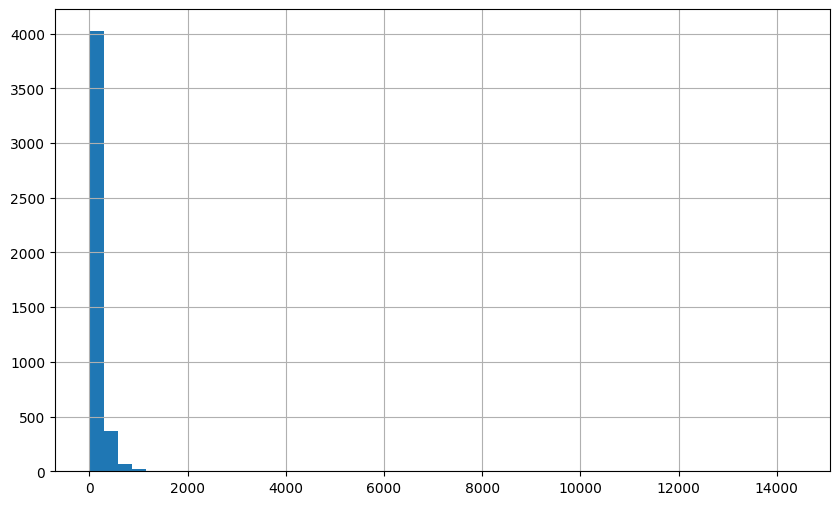

In [20]:
# Check the distribution of the target variable with a histogram. 
df_eda["price"].hist(bins=50, figsize=(10, 6))

<Axes: >

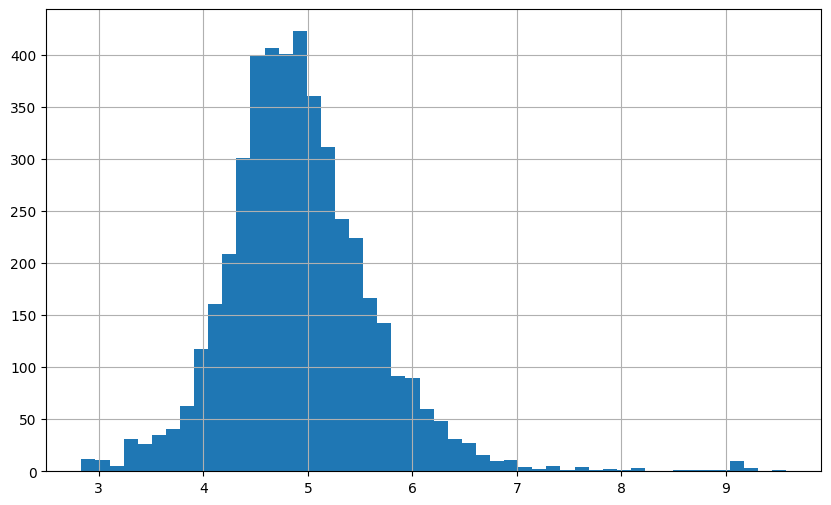

In [21]:
# Check the target variable with a histogram after log transformation. It's more normal now.
np.log1p(df_eda["price"]).hist(bins=50, figsize=(10, 6))

As we can see, the large values are compressed, skewness reduced and the price data is more normal now. 

<Axes: >

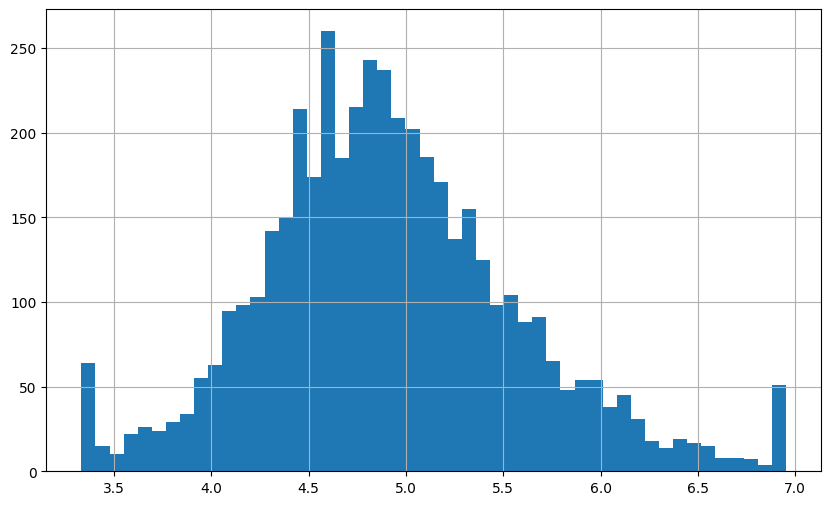

In [22]:
lower = 0.01
upper = 0.99

# Visualize clipped + logged price distribution
price_lower_bound = np.log1p(df_eda["price"]).quantile(lower)
price_upper_bound = np.log1p(df_eda["price"]).quantile(upper)
clipped_logged_price = np.clip(np.log1p(df_eda["price"]), price_lower_bound, price_upper_bound)
clipped_logged_price.hist(bins=50, figsize=(10, 6))

The target variable `price` was highly right-skewed, so its distribution was inspected on the log scale.

To reduce the effect of extreme values during analysis, `log1p(price)` was clipped between the 1st and 99th percentiles and then plotted as a histogram.

##### **4.a. Analysis of Numerical Features**

* **Histograms**

In [23]:
cols_host = ["host_response_rate", "host_acceptance_rate"]

# Convert to numeric percentages
for col in cols_host:
    df[f"{col}_num"] = pd.to_numeric(
        df[col].astype(str).str.replace("%", "", regex=False),
        errors="coerce"
    )

df[[f"{col}_num" for col in cols_host]].describe()

,host_response_rate_num,host_acceptance_rate_num
count,5229.000000,5394.000000
mean,0.947363,0.897293
std,0.168059,0.217875
min,0.000000,0.000000
25%,1.000000,0.930000
50%,1.000000,0.990000
75%,1.000000,1.000000
max,1.000000,1.000000


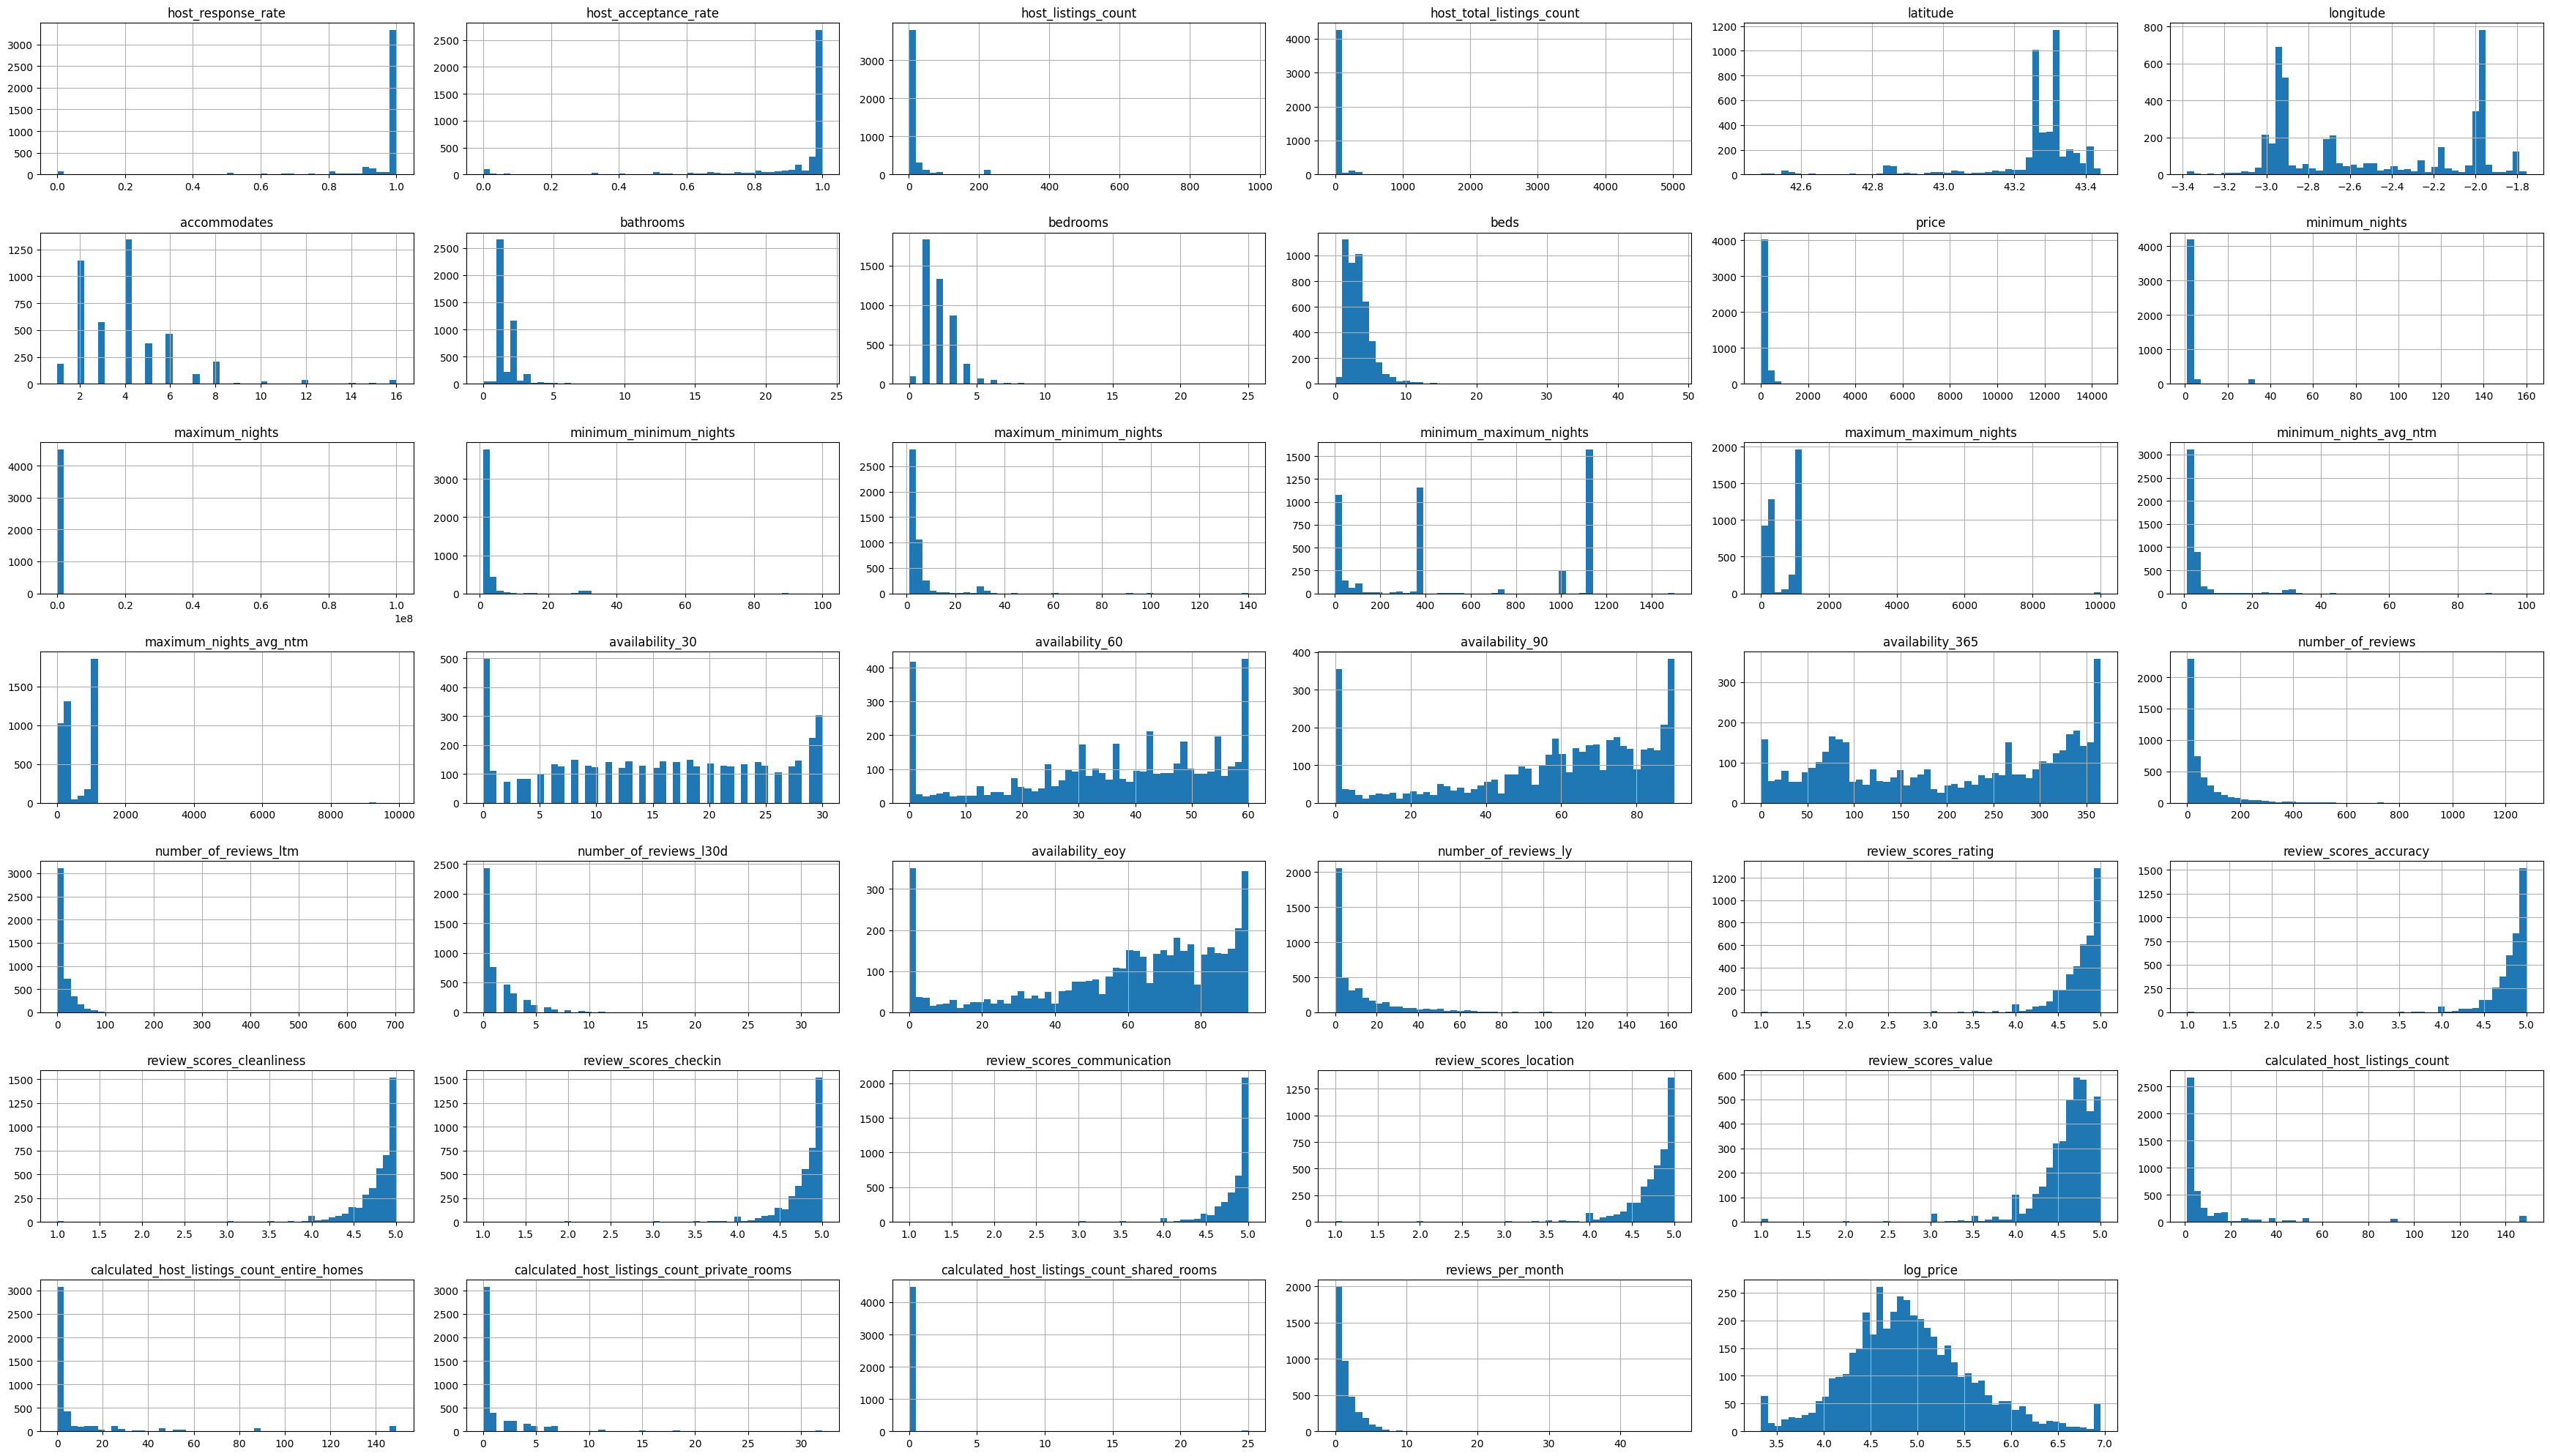

In [24]:
# Clip + log transform the price column and add it to df_eda for further analysis.
df_eda["log_price"] = np.clip(np.log1p(df_eda["price"]), price_lower_bound, price_upper_bound)

# Plot the histograms for all numeric columns in df_eda to 
# check their distributions. We can apply transformations later if needed.
df_eda.select_dtypes(include="number").hist(
    bins=50, 
    figsize=(35, 20), 
    grid=True
)
plt.tight_layout()
plt.show()

df_eda = df_eda.drop(columns=["price"])

* **Correlation Check**

In [25]:
numeric_cols = df_eda.select_dtypes(include="number").columns

In [26]:
corr_matrix = df_eda[numeric_cols].corr()

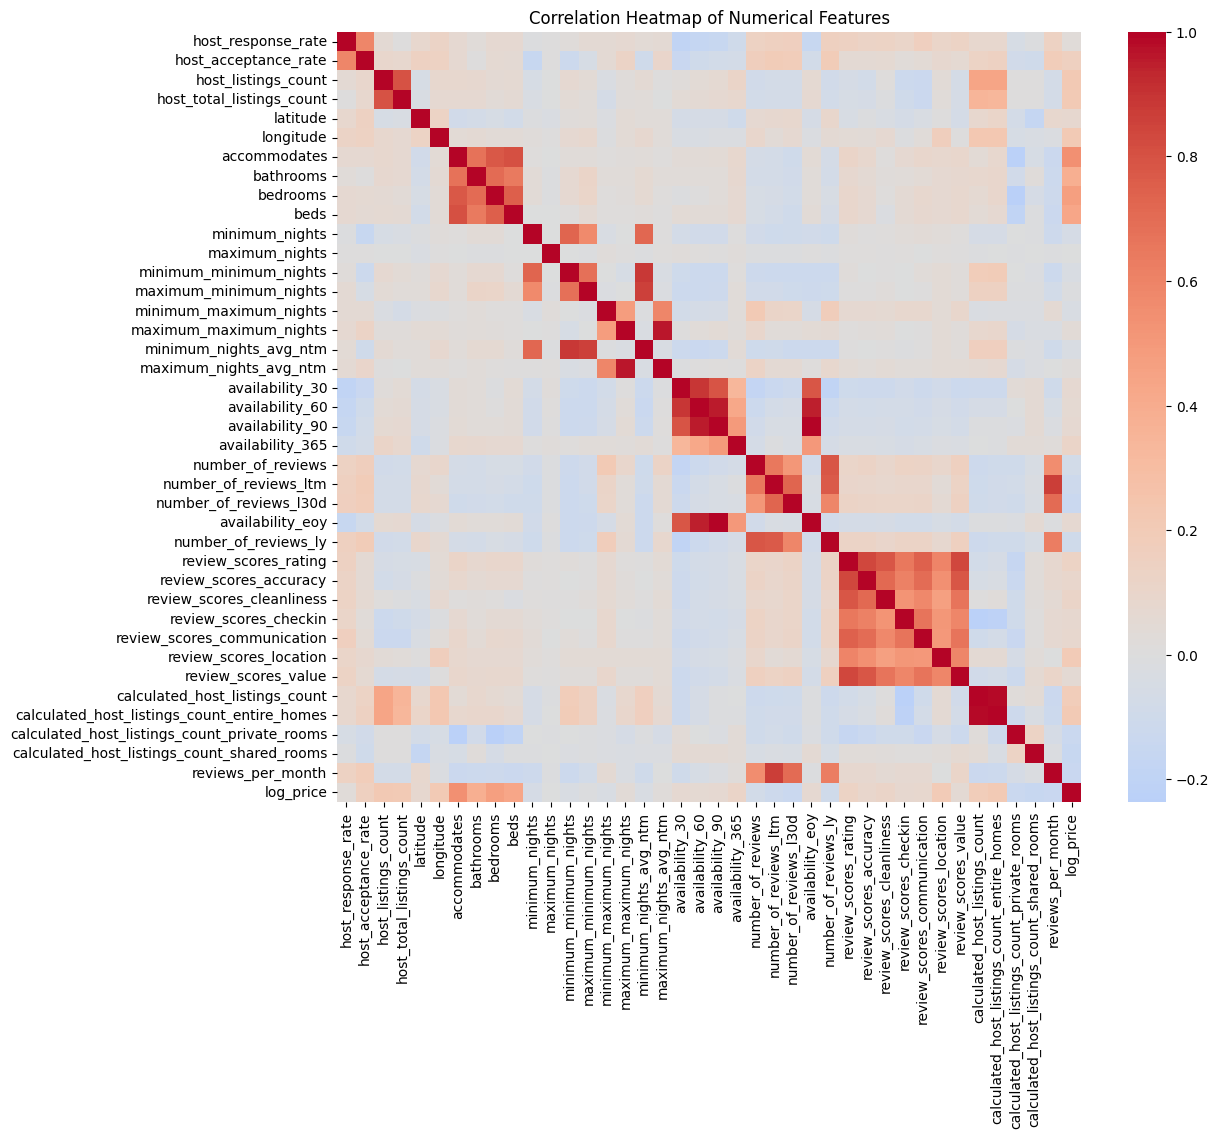

In [27]:
plt.figure(figsize=(12,10))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    annot=False
)

plt.title("Correlation Heatmap of Numerical Features")
plt.show()

In [28]:
df_eda[numeric_cols].corrwith(df_eda["log_price"]).sort_values(ascending=False)

log_price                                       1.000000
accommodates                                    0.542900
bedrooms                                        0.474383
beds                                            0.432933
bathrooms                                       0.383541
host_listings_count                             0.215861
longitude                                       0.210006
host_total_listings_count                       0.209433
calculated_host_listings_count_entire_homes     0.206323
review_scores_location                          0.202186
calculated_host_listings_count                  0.181693
host_acceptance_rate                            0.153424
review_scores_rating                            0.130897
review_scores_cleanliness                       0.113583
availability_365                                0.111386
review_scores_accuracy                          0.092602
review_scores_communication                     0.078130
latitude                       

* Scatterplot

array([[<Axes: xlabel='accommodates', ylabel='accommodates'>,
        <Axes: xlabel='bedrooms', ylabel='accommodates'>,
        <Axes: xlabel='beds', ylabel='accommodates'>,
        <Axes: xlabel='bathrooms', ylabel='accommodates'>,
        <Axes: xlabel='review_scores_location', ylabel='accommodates'>,
        <Axes: xlabel='log_price', ylabel='accommodates'>],
       [<Axes: xlabel='accommodates', ylabel='bedrooms'>,
        <Axes: xlabel='bedrooms', ylabel='bedrooms'>,
        <Axes: xlabel='beds', ylabel='bedrooms'>,
        <Axes: xlabel='bathrooms', ylabel='bedrooms'>,
        <Axes: xlabel='review_scores_location', ylabel='bedrooms'>,
        <Axes: xlabel='log_price', ylabel='bedrooms'>],
       [<Axes: xlabel='accommodates', ylabel='beds'>,
        <Axes: xlabel='bedrooms', ylabel='beds'>,
        <Axes: xlabel='beds', ylabel='beds'>,
        <Axes: xlabel='bathrooms', ylabel='beds'>,
        <Axes: xlabel='review_scores_location', ylabel='beds'>,
        <Axes: xlabel='log_pr

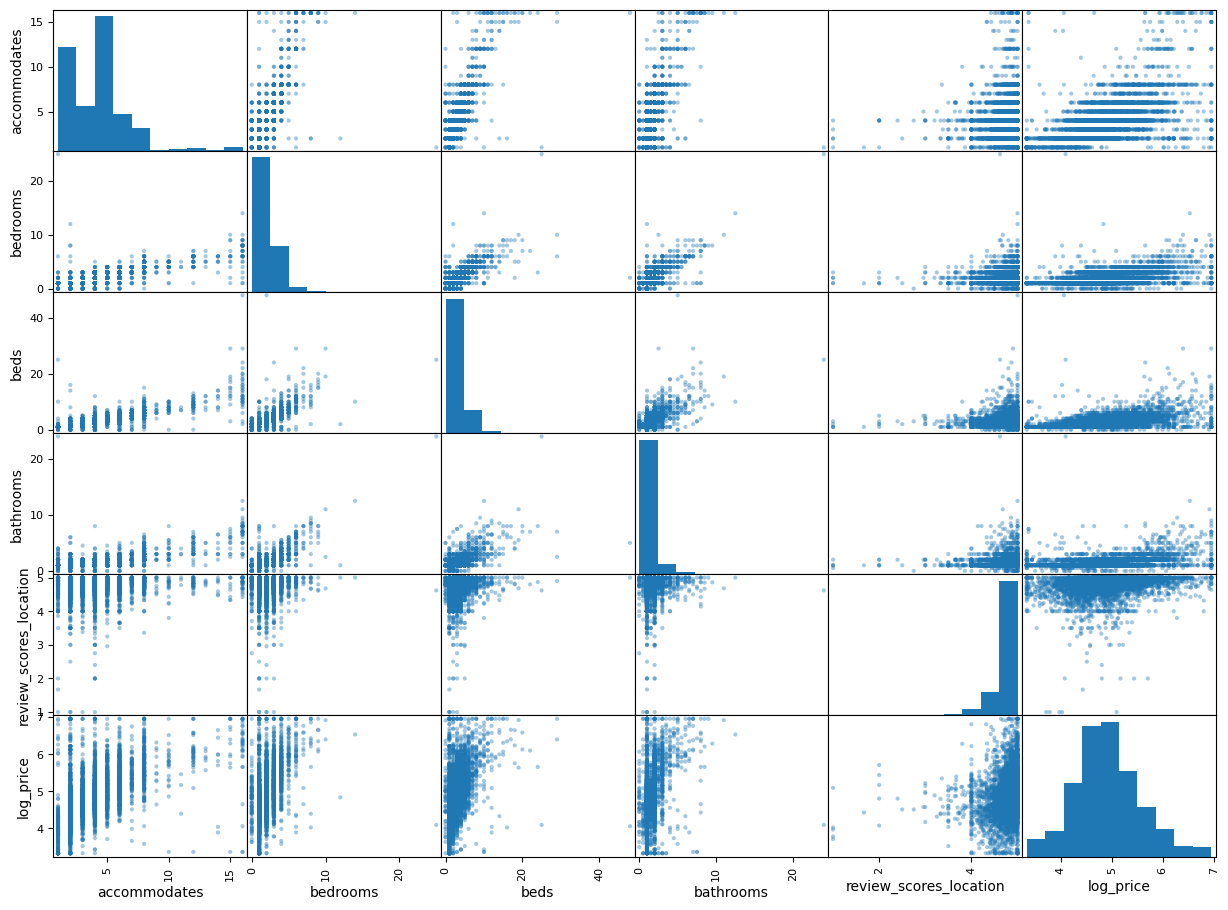

In [29]:
attributes = [
    "accommodates",
    "bedrooms",
    "beds",
    "bathrooms",
    "review_scores_location",
    "log_price" 
]

scatter_matrix(
    df_eda[attributes],
    figsize=(15, 11),
    alpha=0.4
)

* **Checking the log transformation candidates**

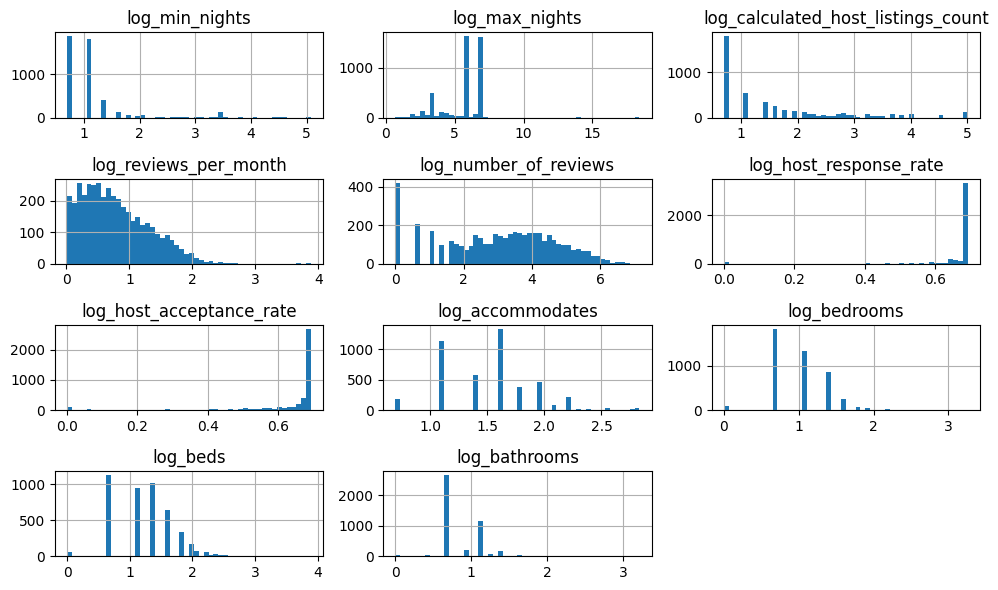

In [30]:
log_candidates = pd.DataFrame({
    "log_min_nights": np.log1p(df_eda["minimum_nights"]),
    "log_max_nights": np.log1p(df_eda["maximum_nights"]),
    "log_calculated_host_listings_count": np.log1p(df_eda["calculated_host_listings_count"]),
    "log_reviews_per_month": np.log1p(df_eda["reviews_per_month"]),
    "log_number_of_reviews": np.log1p(df_eda["number_of_reviews"]),
    "log_host_response_rate": np.log1p(df_eda["host_response_rate"]),
    "log_host_acceptance_rate": np.log1p(df_eda["host_acceptance_rate"]),
    "log_accommodates": np.log1p(df_eda["accommodates"]),
    "log_bedrooms": np.log1p(df_eda["bedrooms"]),
    "log_beds": np.log1p(df_eda["beds"]),
    "log_bathrooms": np.log1p(df_eda["bathrooms"]),
})

log_candidates.hist(bins=50, figsize=(10, 6))
plt.tight_layout()
plt.show()

In [31]:
log_candidates.corrwith(df_eda["log_price"]).sort_values(ascending=False)

log_accommodates                      0.567268
log_bedrooms                          0.473465
log_beds                              0.460479
log_bathrooms                         0.418776
log_host_acceptance_rate              0.149089
log_calculated_host_listings_count    0.122906
log_host_response_rate                0.026314
log_max_nights                        0.016450
log_min_nights                       -0.012339
log_number_of_reviews                -0.088821
log_reviews_per_month                -0.164336
dtype: float64

In [32]:
log_candidates.describe()

,log_min_nights,log_max_nights,log_calculated_host_listings_count,log_reviews_per_month,log_number_of_reviews,log_host_response_rate,log_host_acceptance_rate,log_accommodates,log_bedrooms,log_beds,log_bathrooms
count,4520.000000,4520.000000,4520.000000,4098.000000,4520.000000,4170.000000,4302.000000,4520.000000,4518.000000,4509.000000,4516.000000
mean,1.091558,5.692606,1.632778,0.780645,3.051721,0.660650,0.631821,1.530464,1.022931,1.269314,0.872654
std,0.577528,1.478338,1.132872,0.523842,1.651113,0.112524,0.142347,0.408752,0.375384,0.477610,0.294854
min,0.693147,0.693147,0.693147,0.009950,0.000000,0.000000,0.000000,0.693147,0.000000,0.000000,0.000000
25%,0.693147,5.198497,0.693147,0.364643,1.945910,0.693147,0.657520,1.098612,0.693147,0.693147,0.693147
50%,1.098612,5.902633,1.098612,0.693147,3.258097,0.693147,0.688135,1.609438,1.098612,1.386294,0.693147
75%,1.098612,7.026427,2.197225,1.134623,4.276666,0.693147,0.693147,1.791759,1.386294,1.609438,1.098612
max,5.081404,18.420681,5.010635,3.883829,7.153834,0.693147,0.693147,2.833213,3.258097,3.891820,3.218876


* **Checking the "clip" (or log+clip) candidates**

In [33]:
clip_cols = [
    "beds",
    "minimum_nights",
    "maximum_nights",
    "host_acceptance_rate",
    "bedrooms",
    "bathrooms",
    "beds", "accommodates"
]

clip_candidates = pd.DataFrame()

for col in clip_cols:
    lower = df_eda[col].quantile(0.01)
    upper = df_eda[col].quantile(0.99)
    clipped = df_eda[col].clip(lower=lower, upper=upper)

    if col in ["minimum_nights", "maximum_nights"]:
        clip_candidates[f"log_{col}_clipped"] = np.log1p(clipped)
    else:
        clip_candidates[f"{col}_clipped"] = clipped


In [34]:
clip_candidates.corrwith(df_eda["log_price"]).sort_values(ascending=False)

accommodates_clipped            0.545762
bedrooms_clipped                0.502636
beds_clipped                    0.474404
bathrooms_clipped               0.424270
host_acceptance_rate_clipped    0.153424
log_maximum_nights_clipped      0.021354
log_minimum_nights_clipped     -0.007124
dtype: float64

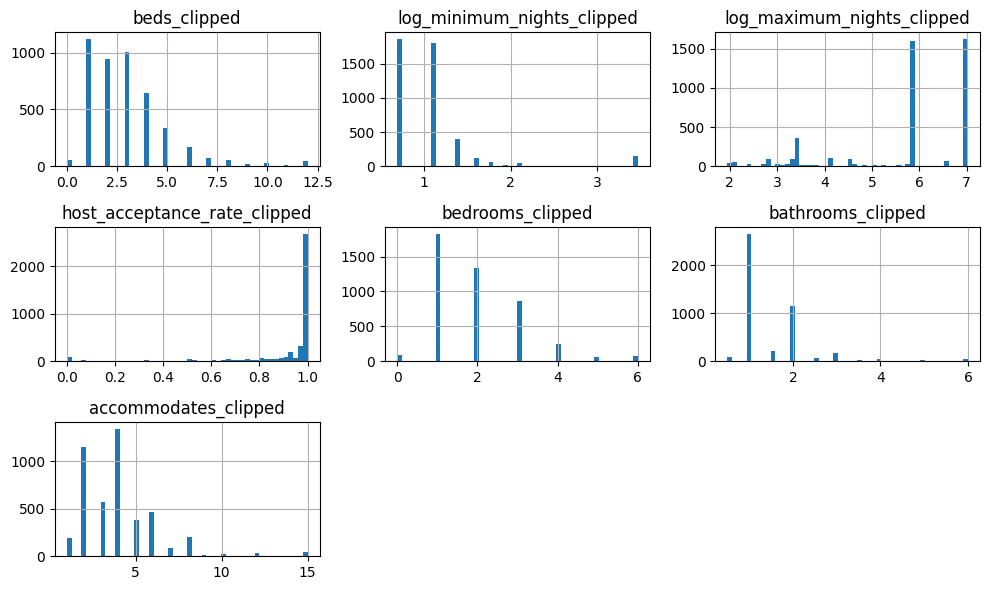

In [35]:
clip_candidates.hist(bins=50, figsize=(10, 6))
plt.tight_layout()
plt.show()


* **Choice of Log and Clipped Features**

    Skewed numeric variables were tested in transformed versions and compared against `log_price` using simple correlation checks. The goal was to keep only the transformations that looked more useful than the raw form.
    
    **Clipped features**
    The following variables were selected for clipping because their distributions contained extreme values and clipping produced a more    reasonable version for modeling:
    
    - `beds`
    - `bathrooms`
    - `bedrooms`
    - `minimum_nights`
    - `maximum_nights`
    - `host_acceptance_rate_num`
    
    **Log-transformed features**
    The following variables were selected for log transformation because their logged versions showed a better or more usable relationship  with `log_price` in the correlation checks:
    
    - `minimum_nights`
    - `accommodates`
    - `maximum_nights`
    - `number_of_reviews`
    - `reviews_per_month`
    
    **Note**
    Some variables, such as `minimum_nights` and `maximum_nights`, were included in both groups. This reflects that both clipping and log transformation were considered useful for handling skewness and extreme values in those features. 
    Although some of these variables remain correlated (for example capacity-related variables and availability metrics), this doesnot pose a significant issue because the final model will use **Ridge Regression**. Ridge regression applies L2regularization, which shrinks coefficients of correlated predictors and mitigates multicollinearity without requiring strictfeature independence.


* **Analysis of Geographical Features**

<Axes: xlabel='longitude', ylabel='latitude'>

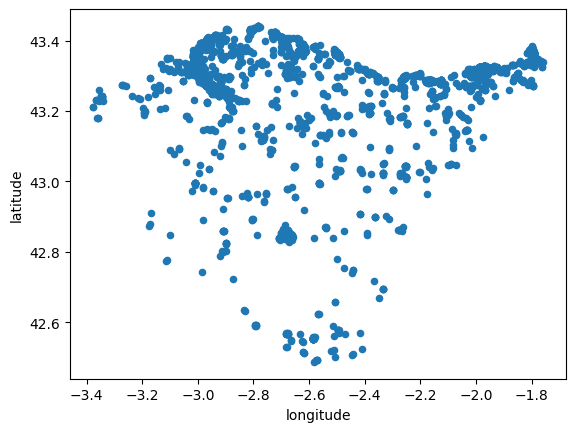

In [36]:
df_eda.plot(kind="scatter", x="longitude", y="latitude")

<Axes: xlabel='longitude', ylabel='latitude'>

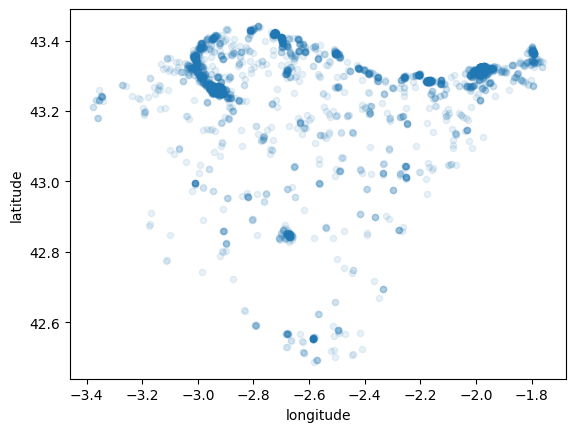

In [37]:
df_eda.plot(kind="scatter", x="longitude", y="latitude", alpha=0.1)

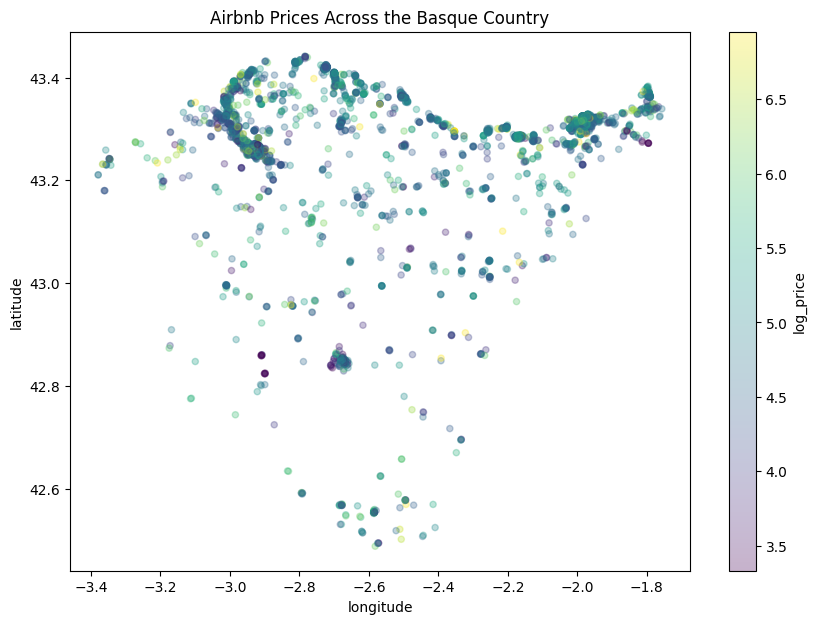

In [38]:
df_eda.plot(
    kind="scatter",
    x="longitude",
    y="latitude",
    alpha=0.3,
    c="log_price", 
    cmap="viridis",
    colorbar=True,
    figsize=(10,7)
)

plt.title("Airbnb Prices Across the Basque Country")
plt.show()

In [39]:
# 1. Define a Basque Country reference point for one distance feature
BASQUE_COUNTRY_REFERENCE_LAT = 43.2630
BASQUE_COUNTRY_REFERENCE_LON = -2.9350

# 2. Calculate the basic Euclidean distance
df_eda["distance_to_basque_country_reference"] = np.sqrt(
    (df_eda["latitude"] - BASQUE_COUNTRY_REFERENCE_LAT)**2 + 
    (df_eda["longitude"] - BASQUE_COUNTRY_REFERENCE_LON)**2
)

df_eda[["distance_to_basque_country_reference", "longitude", "latitude"]].corrwith(df_eda["log_price"])

distance_to_basque_country_reference    0.205753
longitude                               0.210006
latitude                                0.073938
dtype: float64

In [40]:
DONOSTIA_LAT = 43.3183
DONOSTIA_LON = -1.9812

df_eda["distance_to_donostia"] = np.sqrt(
    (df_eda["latitude"] - DONOSTIA_LAT)**2 + 
    (df_eda["longitude"] - DONOSTIA_LON)**2
)

df_eda[["distance_to_donostia", "longitude", "latitude"]].corrwith(df_eda["log_price"])

distance_to_donostia   -0.228691
longitude               0.210006
latitude                0.073938
dtype: float64

In [41]:
VITORIA_LAT = 42.8467
VITORIA_LON = -2.6726

df_eda["distance_to_vitoria"] = np.sqrt(
    (df_eda["latitude"] - VITORIA_LAT)**2 + 
    (df_eda["longitude"] - VITORIA_LON)**2
)

df_eda[["distance_to_vitoria", "longitude", "latitude"]].corrwith(df_eda["log_price"])

distance_to_vitoria    0.223179
longitude              0.210006
latitude               0.073938
dtype: float64

In [42]:
COAST_LAT = 43.3623
COAST_LON = -3.0136

df_eda["distance_to_coast"] = np.sqrt(
    (df_eda["latitude"] - COAST_LAT)**2 + 
    (df_eda["longitude"] - COAST_LON)**2
)

df_eda[["distance_to_coast", "longitude", "latitude"]].corrwith(df_eda["log_price"])

distance_to_coast    0.203635
longitude            0.210006
latitude             0.073938
dtype: float64

* Geographic Feature Engineering

    Since the dataset contains listings across the entire **Basque Country**, using raw geographic coordinates  (`latitude`, `longitude`) in a **linear model such as Ridge Regression** is not ideal. Linear models cannot easily   capture spatial relationships directly from coordinates.

    Instead, I engineered **distance-based features** that better represent location effects on price:

    - `distance_to_basque_country_reference`
    - `distance_to_donostia`
    - `distance_to_vitoria`
    - `distance_to_coast`

    These were computed using the Euclidean distance between each listing's coordinates and the reference location.

    Correlation checks show that these distance features have **stronger and more interpretable relationships with  `log_price`** than raw coordinates, making them more suitable inputs for the model.


* List of numerical columns to keep:
    - log_price
    - host_listings_count
    - host_total_listings_count
    - log_accommodates
    - bathrooms_clipped
    - bedrooms_clipped
    - beds_clipped
    - log_minimum_nights_clipped
    - log_maximum_nights_clipped
    - availability_30
    - availability_90
    - availability_365
    - log_number_of_reviews
    - log_reviews_per_month
    - review_scores_rating
    - review_scores_cleanliness
    - review_scores_location
    - calculated_host_listings_count_entire_homes
    - calculated_host_listings_count_private_rooms
    - calculated_host_listings_count_shared_rooms
    - host_acceptance_rate_clipped
    - distance_to_coast
    - distance_to_vitoria
    - distance_to_donostia
    - distance_to_center
    - longitude
    - latitude

##### **4.b. Analysis of Categorical Features**

In [43]:
# Get a list of all categorical columns
categorical_cols = df_eda.select_dtypes(include=["object", "string"]).columns

print(len(categorical_cols))
categorical_cols

19


Index(['last_scraped', 'host_since', 'host_location', 'host_response_time',
       'host_is_superhost', 'host_neighbourhood', 'host_has_profile_pic',
       'host_identity_verified', 'neighbourhood', 'neighbourhood_cleansed',
       'neighbourhood_group_cleansed', 'property_type', 'room_type',
       'amenities', 'has_availability', 'first_review', 'last_review',
       'license', 'instant_bookable'],
      dtype='str')

In [44]:
df_eda[categorical_cols].head()

,last_scraped,host_since,host_location,host_response_time,host_is_superhost,host_neighbourhood,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,property_type,room_type,amenities,has_availability,first_review,last_review,license,instant_bookable
1592,2025-09-30,2019-06-08,"Bilbao, Spain",within an hour,t,NaN,t,t,"Bilbao, Vizkaia, Spain, Spain",Bilbao,Vizcaya,Entire rental unit,Entire home/apt,"[""Pack \u2019n play/Travel crib"", ""Refrigerato...",t,2019-06-15,2025-09-24,ESFCTU00004802700084705300000000000000000000EB...,f
1382,2025-09-30,2017-06-04,"San Sebastián, Spain",within a few hours,f,NaN,t,t,"Donostia-San Sebastian, Euskadi, Spain",Donostia-San SebastiÃ¡n,GuipÃºzcoa,Entire rental unit,Entire home/apt,"[""Refrigerator"", ""Microwave"", ""Hot water kettl...",t,2019-06-30,2025-07-31,ESFCNT0000200080002542430000000000000000000000...,f
2536,2025-09-30,2012-05-26,"San Sebastián, Spain",within an hour,t,NaN,t,t,"Donostia-San Sebastian, Euskadi, Spain",Donostia-San SebastiÃ¡n,GuipÃºzcoa,Entire rental unit,Entire home/apt,"[""Pack \u2019n play/Travel crib"", ""Refrigerato...",t,2021-07-31,2025-09-28,ESFCTU00002000800051403300000000000000000000ES...,t
986,2025-09-30,2018-03-17,"Donostia-San Sebastian, Spain",within an hour,t,NaN,t,t,"Donostia-San Sebastian, Euskadi, Spain",Donostia-San SebastiÃ¡n,GuipÃºzcoa,Entire rental unit,Entire home/apt,"[""Pack \u2019n play/Travel crib"", ""Children\u2...",t,2018-03-25,2025-09-27,ESFCTU00002000800023810600000000000000000000ES...,t
4449,2025-09-30,2021-08-13,NaN,within an hour,f,Nové Město,t,t,"Gasteiz, Euskadi, Spain",Vitoria-Gasteiz,Ãlava,Entire rental unit,Entire home/apt,"[""Refrigerator"", ""Microwave"", ""Shower gel"", ""E...",t,2024-02-28,2025-01-06,Exempt,t


In [45]:
cat_cols_to_drop = [
    "first_review", 
    "last_review", "license",
    "host_location", "host_neighbourhood"
]

df_eda = df_eda.drop(columns=cat_cols_to_drop, errors="ignore")

In [46]:
print(f"Unique property types: {df_eda['property_type'].nunique()}")
print(f"Unique neighborhood groups: {df_eda['neighbourhood_group_cleansed'].nunique()}")
print(f"Unique neighborhoods: {df_eda['neighbourhood'].nunique()}")
print(f"Unique neighborhood cleansed: {df_eda['neighbourhood_cleansed'].nunique()}")
print(f"Unique host response time types: {df_eda['host_response_time'].nunique()}")

Unique property types: 61
Unique neighborhood groups: 3
Unique neighborhoods: 379
Unique neighborhood cleansed: 201
Unique host response time types: 4


In [47]:
# Calculate the percentage of total listings for each property type
prop_percentages = df_eda["property_type"].value_counts(normalize=True) * 100
print(prop_percentages.head(15).round(2).astype(str) + '%')

property_type
Entire rental unit                   57.19%
Private room in rental unit          10.44%
Entire home                           5.46%
Private room in home                  4.54%
Room in hotel                         2.04%
Private room in bed and breakfast     1.88%
Entire condo                          1.84%
Entire cottage                        1.81%
Private room in hostel                1.46%
Private room in cottage               1.26%
Entire serviced apartment             0.82%
Room in boutique hotel                0.82%
Entire villa                          0.75%
Entire loft                           0.75%
Entire townhouse                      0.64%
Name: proportion, dtype: str


In [48]:
# Define how many top categories you want to keep
TOP_K = 10

# PROPERTY TYPE
top_properties = df_eda["property_type"].value_counts().nlargest(TOP_K).index

df_eda["property_type_clean"] = df_eda["property_type"].where(
    df_eda["property_type"].isin(top_properties),
    "Other"
)

# NEIGHBOURHOOD CLEANSED
top_neighbourhoods_cleansed = (
    df_eda["neighbourhood_cleansed"]
    .value_counts()
    .nlargest(TOP_K)
    .index
)

df_eda["neighbourhood_cleansed_clean"] = df_eda["neighbourhood_cleansed"].where(
    df_eda["neighbourhood_cleansed"].isin(top_neighbourhoods_cleansed),
    "Other"
)

# NEIGHBOURHOOD
top_neighbourhoods = (
    df_eda["neighbourhood"]
    .value_counts()
    .nlargest(TOP_K)
    .index
)

df_eda["neighbourhood_clean"] = df_eda["neighbourhood"].where(
    df_eda["neighbourhood"].isin(top_neighbourhoods),
    "Other"
)

# Prove it worked
print("Property types:")
print(df_eda["property_type_clean"].value_counts())

print("\nNeighbourhood cleansed:")
print(df_eda["neighbourhood_cleansed_clean"].value_counts())

print("\nNeighbourhood:")
print(df_eda["neighbourhood_clean"].value_counts())

Property types:
property_type_clean
Entire rental unit                   2585
Other                                 546
Private room in rental unit           472
Entire home                           247
Private room in home                  205
Room in hotel                          92
Private room in bed and breakfast      85
Entire condo                           83
Entire cottage                         82
Private room in hostel                 66
Private room in cottage                57
Name: count, dtype: int64

Neighbourhood cleansed:
neighbourhood_cleansed_clean
Other                      1487
Donostia-San SebastiÃ¡n    1152
Bilbao                     1123
Zarautz                     130
Vitoria-Gasteiz             124
Bermeo                      124
Getxo                       111
Hondarribia                  92
Barakaldo                    67
Mundaka                      59
Sopelana                     51
Name: count, dtype: int64

Neighbourhood:
neighbourhood_clean
Other   

* Why `neighbourhood_cleansed` is used instead of other neighbourhood features

    The dataset contains three location-related variables: `neighbourhood`, `neighbourhood_group_cleansed`, and     `neighbourhood_cleansed`.
    
    - `neighbourhood` contains inconsistent text strings (e.g., different free-text location spellings),     which creates redundant categories and noise.
    - `neighbourhood_group_cleansed` is too coarse, containing only a few broad geographic groups.
    - `neighbourhood_cleansed` provides standardized municipality names (e.g., Basque Country municipalities such as Getxo and Donostia-San Sebastián),  giving a better balance between **data quality and geographic detail**.
    
    Therefore, `neighbourhood_cleansed` is retained for feature engineering while the other two variables are dropped.

In [49]:
df_eda.groupby("neighbourhood_cleansed_clean")["log_price"].median().sort_values()

neighbourhood_cleansed_clean
Vitoria-Gasteiz            4.470838
Bermeo                     4.505335
Barakaldo                  4.595120
Other                      4.727388
Mundaka                    4.812184
Bilbao                     4.812184
Sopelana                   4.812184
Getxo                      4.828314
Hondarribia                4.948760
Zarautz                    5.043425
Donostia-San SebastiÃ¡n    5.201252
Name: log_price, dtype: float64

* What the `neighbourhood_cleansed` – `log_price` analysis shows

    The median `log_price` was computed for each `neighbourhood_cleansed`.
    
    The results show large variation in prices across locations, with median `log_price` values ranging roughly from **3.   3 to over 6**. After converting from the logarithmic scale, this corresponds to substantial differences in actual  listing prices.
    
    This indicates that **location is a strong driver of Airbnb prices**, confirming the importance of including a  reliable geographic feature in the model.

In [50]:
loc_cols_to_drop = [
   "neighbourhood", "neighbourhood_group_cleansed"
]

# Drop them from your EDA dataframe
df_eda = df_eda.drop(columns=loc_cols_to_drop, errors="ignore")

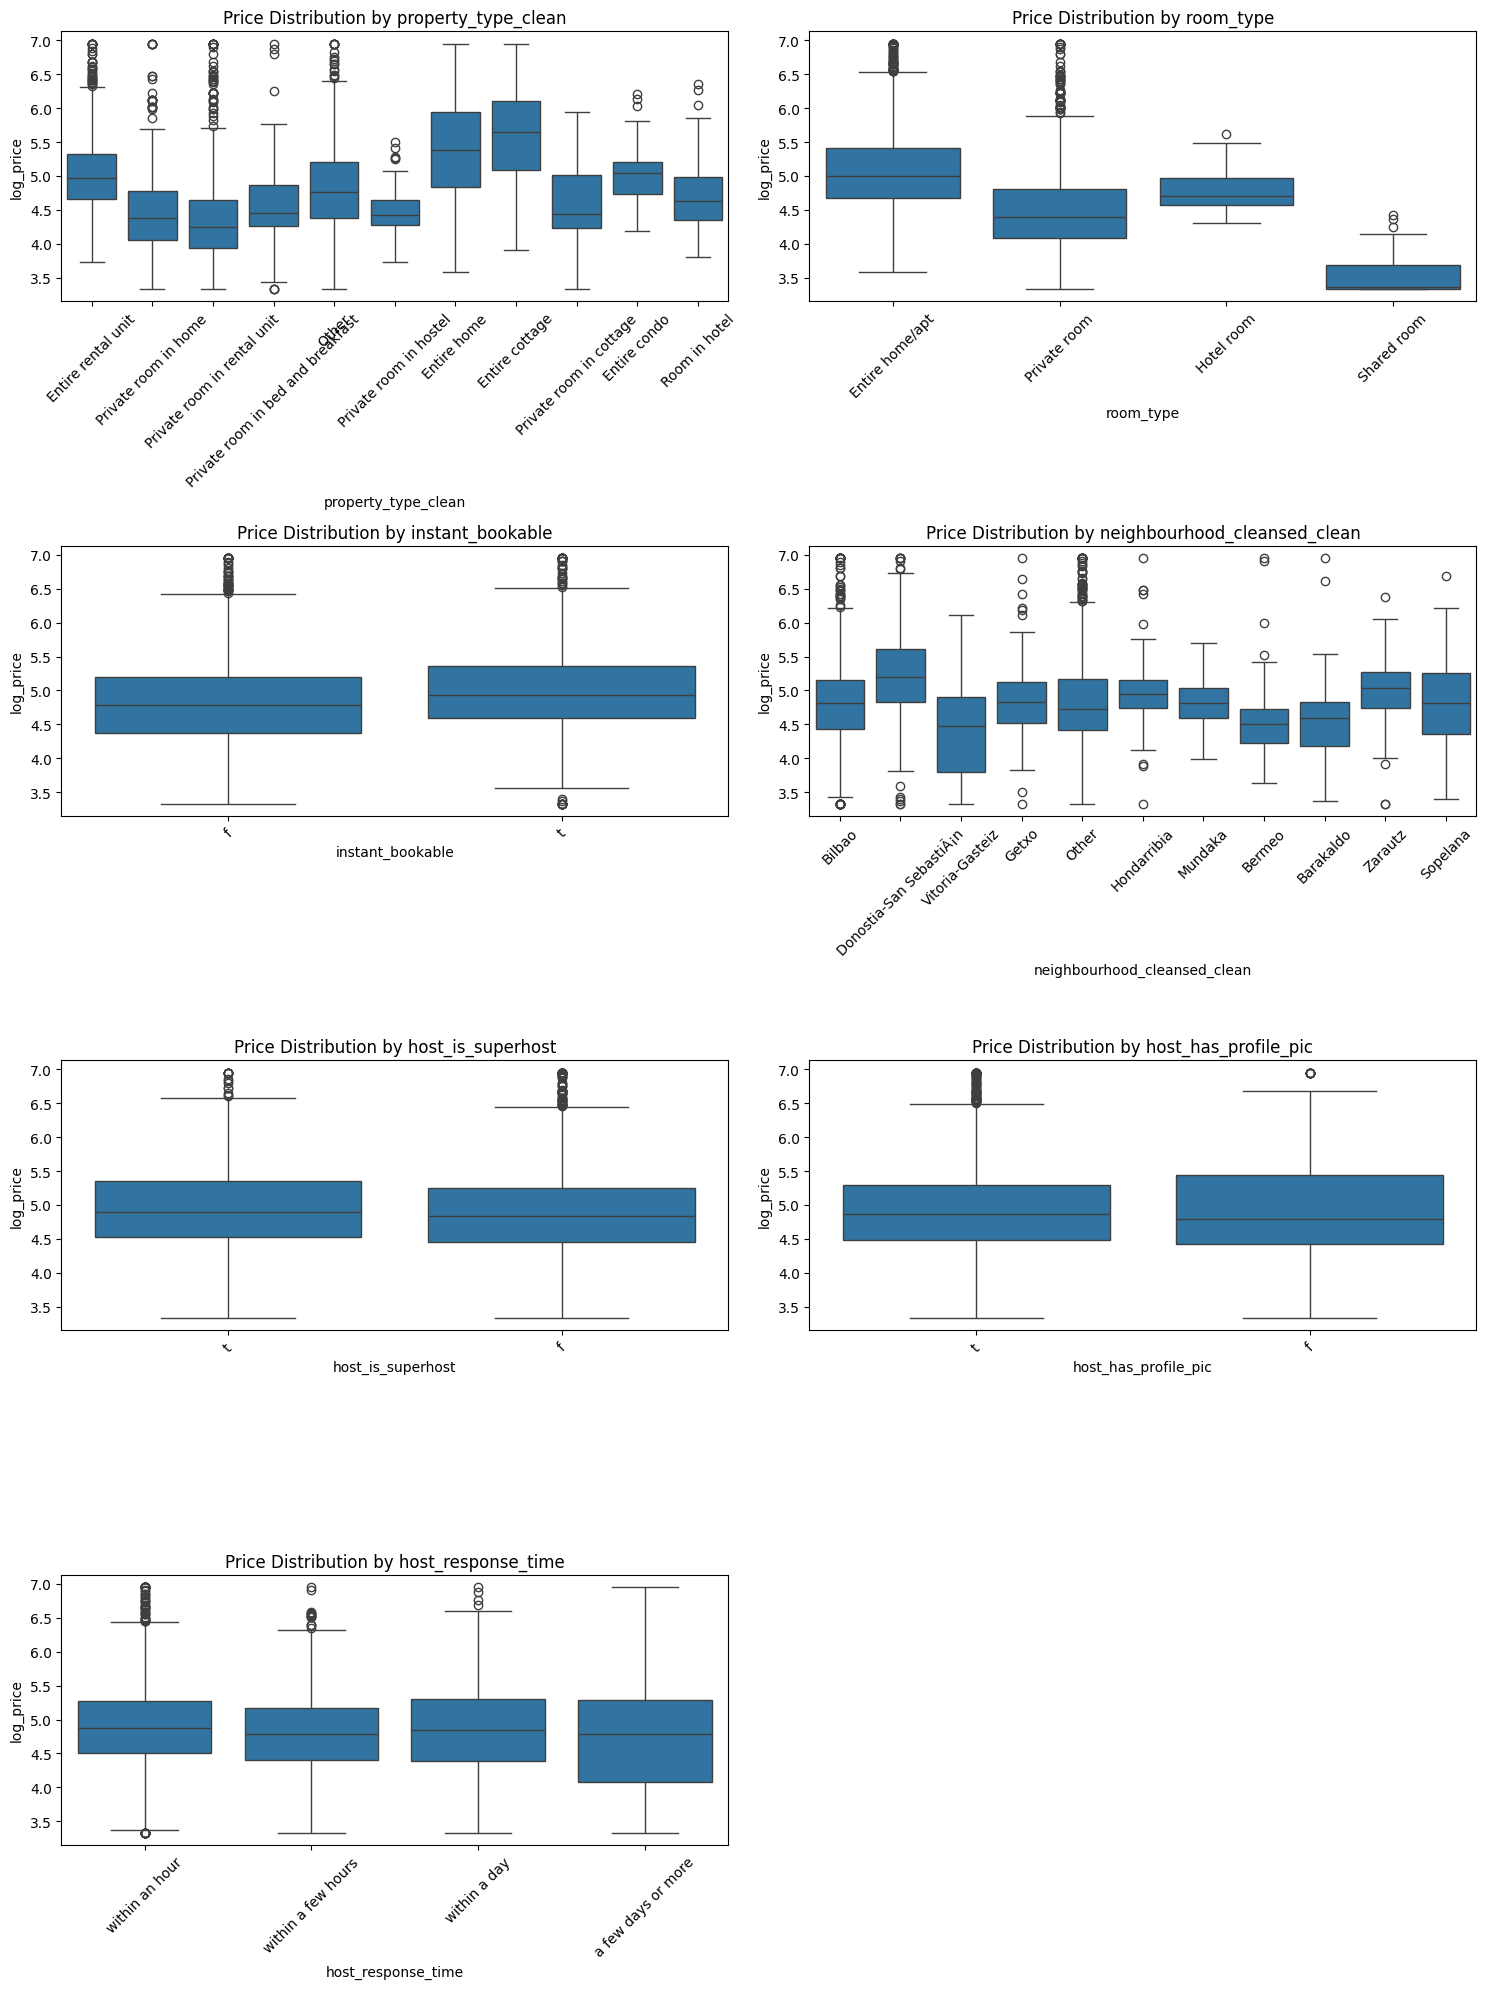

In [51]:
cat_cols = [
    "property_type_clean",
    "room_type",
    "instant_bookable",
    "neighbourhood_cleansed_clean",
    "host_is_superhost",
    "host_has_profile_pic",
    "host_response_time"
]

n_plot_cols = 2
n_plot_rows = (len(cat_cols) + n_plot_cols - 1) // n_plot_cols

fig, axes = plt.subplots(n_plot_rows, n_plot_cols, figsize=(15, 5 * n_plot_rows))
axes = np.atleast_1d(axes).flatten()

for i, col in enumerate(cat_cols):
    sns.boxplot(data=df_eda, x=col, y="log_price", ax=axes[i])
    axes[i].set_title(f"Price Distribution by {col}")
    axes[i].tick_params(axis="x", rotation=45)

for ax in axes[len(cat_cols):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()


* Categorical Feature Exploration

    These boxplots show how **log-transformed price (`log_price`)** varies across key categorical variables.

    - **property_type_clean**: Different property types show noticeable differences in price distribution. Entire homes     and cottages tend to have higher median prices than private rooms or hostel-type listings.

    - **room_type**: This variable has a clear relationship with price. Entire homes/apartments have the highest median     prices, while shared rooms have the lowest.

    - **instant_bookable**: Listings that can be instantly booked show a slightly higher median price, though the   difference appears relatively small.

    - **neighbourhood_cleansed_clean**: Price distributions vary across locations, suggesting that neighbourhood plays an   important role in determining listing price.

    Overall, **room type and neighbourhood appear to be the strongest categorical signals for price**, while **instant  booking status shows a weaker effect**.

##### **4.c. Host Tenure Analysis**

In this subsection, I analyze **host tenure** by converting the date variables into a usable datetime format and calculating how long each host has been active on the platform. From this, I create features such as `host_experience_days` and `host_experience_years`, which capture the host’s level of experience at the time of data collection.

The aim is to examine whether more experienced hosts tend to charge different prices than newer hosts. I summarize the distribution of host experience and check its relationship with `log_price` to assess whether host tenure may be a useful predictor in the final model.


In [52]:
df_eda["last_scraped"] = pd.to_datetime(df["last_scraped"], errors="coerce")
df_eda["last_scraped"].max()

Timestamp('2025-09-30 00:00:00')

In [53]:
df_eda["host_since"] = pd.to_datetime(df_eda["host_since"], errors="coerce")
reference_date = pd.Timestamp("2025-09-30")
df_eda["host_experience_days"] = (reference_date - df_eda["host_since"]).dt.days
df_eda["host_experience_years"] = df_eda["host_experience_days"] / 365.25

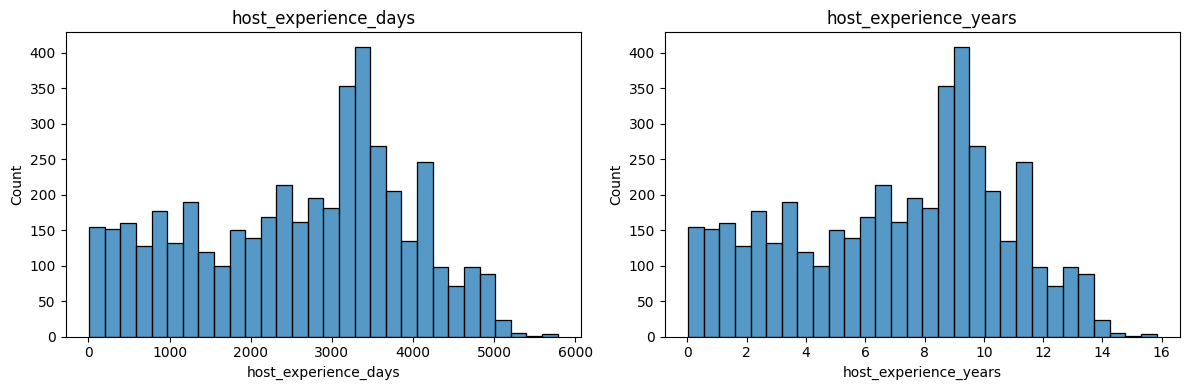

In [54]:
date_cols = ["host_experience_days", "host_experience_years"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col in zip(axes, date_cols):
    sns.histplot(df_eda[col], bins=30, ax=ax)
    ax.set_title(col)

plt.tight_layout()

In [55]:
df_eda["host_experience_days"].describe()

count    4518.000000
mean     2573.720009
std      1327.918388
min         8.000000
25%      1440.500000
50%      2794.500000
75%      3538.000000
max      5781.000000
Name: host_experience_days, dtype: float64

In [56]:
df_eda[["host_experience_days", "log_price"]].corr()

,host_experience_days,log_price
host_experience_days,1.000000,0.054884
log_price,0.054884,1.000000


##### **4.d. The Analysis of Amenities**

In this subsection, I explore the **amenities** offered by each listing to understand whether certain features are associated with higher prices. Since amenities are stored as text-based lists, they first need to be parsed and transformed into a structured format before they can be analyzed properly.

The goal is to identify which amenities are most common, which ones appear more often in higher-priced listings, and whether some features may act as indicators of more premium properties. This analysis helps uncover additional signals beyond location, capacity, and host characteristics that may improve the final model.


In [57]:
# preview the raw amenities
print(df_eda["amenities"].head(5))

1592    ["Pack \u2019n play/Travel crib", "Refrigerato...
1382    ["Refrigerator", "Microwave", "Hot water kettl...
2536    ["Pack \u2019n play/Travel crib", "Refrigerato...
986     ["Pack \u2019n play/Travel crib", "Children\u2...
4449    ["Refrigerator", "Microwave", "Shower gel", "E...
Name: amenities, dtype: str


In [58]:
# Parse amenities
def parse_amenities(value):
    if pd.isna(value) or value == "":
        return []
    if isinstance(value, list):
        parsed = value
    else:
        try:
            parsed = ast.literal_eval(value)
        except (ValueError, SyntaxError):
            return []
    return [str(amenity).strip().strip('"') for amenity in parsed if str(amenity).strip()]

amenities_lists = df_eda["amenities"].apply(parse_amenities)
amenities_sets = amenities_lists.apply(set)

# Count amenities
amenities_counts = pd.Series(
    [amenity for sublist in amenities_lists for amenity in sublist]
).value_counts()

print("Total unique amenities:", amenities_counts.shape[0])

Total unique amenities: 1442


In [59]:
# Define a minimum share threshold (e.g., 5% of listings) to select amenities
min_share = 0.05
min_count = int(len(df_eda) * min_share)

selected_amenities = amenities_counts[amenities_counts >= min_count].index.tolist()
len(selected_amenities)

99

In [60]:
# Analyze the price impact of each selected amenity by comparing the median 
# log price of listings with and without the amenity.

# Number of listings in the EDA dataset
n_listings = len(df_eda)

# Keep only amenities that appear often enough to be meaningful
MIN_SHARE = 0.05   # at least 5% of listings
MIN_COUNT = int(n_listings * MIN_SHARE)

candidate_amenities = amenities_counts[amenities_counts >= MIN_COUNT].index.tolist()

# Build relevance table
results = []

for amenity in candidate_amenities:
    has_amenity = amenities_sets.apply(lambda s: amenity in s)

    median_with = df_eda.loc[has_amenity, "log_price"].median()
    median_without = df_eda.loc[~has_amenity, "log_price"].median()

    diff_log = median_with - median_without
    approx_pct_diff = (np.exp(diff_log) - 1) * 100

    results.append({
        "amenity": amenity,
        "count": has_amenity.sum(),
        "share_listings_pct": has_amenity.mean() * 100,
        "median_log_price_with": median_with,
        "median_log_price_without": median_without,
        "diff_log_price": diff_log,
        "approx_price_diff_pct": approx_pct_diff
    })

amenity_impact = pd.DataFrame(results)

# Rank by strongest price effect
amenity_impact = amenity_impact.sort_values(
    by="diff_log_price",
    key=lambda s: s.abs(),
    ascending=False
).reset_index(drop=True)

# Show the most price-relevant amenities
amenity_impact.head(20)


,amenity,count,share_listings_pct,median_log_price_with,median_log_price_without,diff_log_price,approx_price_diff_pct
0,Lock on bedroom door,434,9.601770,4.330733,4.912655,-0.581922,-44.117647
1,Kitchen,3802,84.115044,4.919981,4.537947,0.382034,46.526159
2,Dishwasher,2247,49.712389,5.030438,4.682131,0.348307,41.666667
3,Indoor fireplace,282,6.238938,5.159055,4.852030,0.307025,35.937500
4,BBQ grill,396,8.761062,5.150359,4.848109,0.302251,35.290043
5,Paid parking garage off premises,283,6.261062,5.153292,4.852030,0.301261,35.156250
6,Crib,1164,25.752212,5.087596,4.787492,0.300105,35.000000
7,High chair,731,16.172566,5.087596,4.828314,0.259283,29.600000
8,Free dryer – In unit,334,7.389381,5.108967,4.852030,0.256936,29.296285
9,Crib - available upon request,423,9.358407,5.075174,4.844187,0.230987,25.984252


In [61]:
display(amenities_counts.head(100))

Wifi                                                 4032
Kitchen                                              3802
Hair dryer                                           3627
Hot water                                            3615
Bed linens                                           3274
                                                     ... 
Radiant heating                                       241
Keypad                                                231
Pack ’n play/Travel crib - available upon request     231
Induction stove                                       231
Barbecue utensils                                     217
Name: count, Length: 100, dtype: int64

In [62]:
# Analyze the amenities of the most expensive listings to see if there are any common features.

top_expensive_idx = df_eda.sort_values("log_price", ascending=False).head(50).index

top_expensive_amenities = amenities_lists.loc[top_expensive_idx]

top_expensive_counts = pd.Series(
    [amenity for sublist in top_expensive_amenities for amenity in sublist]
).value_counts()

display(top_expensive_counts.head(100))

Wifi                        46
Washer                      37
Kitchen                     37
TV                          31
Free parking on premises    30
                            ..
Exercise equipment           2
EV charger                   2
Ping pong table              2
Pool                         2
Laundromat nearby            2
Name: count, Length: 100, dtype: int64

In [63]:
# Check which of the most common amenities among the expensive listings are not in 
# the selected amenities list.

top_expensive_rare_counts = pd.Series(
    [
        amenity
        for sublist in top_expensive_amenities
        for amenity in sublist
        if amenity not in selected_amenities
    ]
).value_counts()

display(top_expensive_rare_counts.head(50))

Breakfast                                                     11
Sound system                                                  11
Barbecue utensils                                              5
Outdoor shower                                                 5
Fire pit                                                       4
River view                                                     4
Sun loungers                                                   4
Beach essentials                                               3
Beach access – Beachfront                                      3
Babysitter recommendations                                     3
Private pool                                                   3
Indoor fireplace: wood-burning                                 2
Valley view                                                    2
AC - split type ductless system                                2
Outlet covers                                                  2
Arcade games             

In [64]:
# Define a list of luxury-related keywords to check for in the amenities.
luxury_keywords = [
    "view",
    "beachfront",
    "beach access",
    "pool",
    "hot tub",
    "fireplace",
    "gym",
    "ev charger"
]
# Create a binary feature indicating whether a listing has any luxury-related amenity.
df_eda["has_luxury_amenity"] = amenities_lists.apply(
    lambda row: int(any(
        keyword in amenity.lower()
        for amenity in row
        for keyword in luxury_keywords
    ))
)
# Create a count feature for the number of luxury-related amenities.
df_eda["luxury_amenity_count"] = amenities_lists.apply(
    lambda row: sum(
        any(keyword in amenity.lower() for keyword in luxury_keywords)
        for amenity in row
    )
)

In [65]:
# Check the correlation of these new features with log_price.
display(
    df_eda[["log_price", "has_luxury_amenity", "luxury_amenity_count"]]
    .corr(numeric_only=True)
)

,log_price,has_luxury_amenity,luxury_amenity_count
log_price,1.000000,0.177784,0.200222
has_luxury_amenity,0.177784,1.000000,0.677487
luxury_amenity_count,0.200222,0.677487,1.000000


In [66]:
# Bin log_price into quartiles and analyze the average presence of luxury amenities 
# in each price bin.
df_eda["price_bin"] = pd.qcut(
    df_eda["log_price"],
    q=4,
    labels=["low", "mid_low", "mid_high", "high"]
)

display(
    df_eda.groupby("price_bin")[["has_luxury_amenity", "luxury_amenity_count"]]
    .agg(["mean", "median"])
)

has_luxury_amenity        luxury_amenity_count       
                        mean median                 mean median
price_bin                                                      
low                 0.333916    0.0             0.586538    0.0
mid_low             0.399823    0.0             0.751773    0.0
mid_high            0.420912    0.0             0.853441    0.0
high                0.551816    1.0             1.305580    1.0

Overall, the amenities analysis shows that not all amenities contribute equally to explaining price differences. While many common amenities are widely available across listings and offer limited predictive value, a smaller group of more distinctive features appears to be associated with higher-priced properties and may serve as indicators of quality or premium positioning.

This step helps move the amenities variable from an unstructured text field to a more meaningful source of information for modeling. The insights gained here support the selection of the most relevant amenities-related features and help ensure that only useful signals are carried forward into the preprocessing and modeling stages.


##### **4.d. Missing Value Strategy**

In [67]:
# Check the percentage of missing values in each column to decide on imputation or dropping.
missing_cols = df_eda.isnull().mean().mul(100).sort_values(ascending=False)
missing_cols[missing_cols > 0]

reviews_per_month              9.336283
review_scores_cleanliness      9.336283
review_scores_communication    9.336283
review_scores_location         9.336283
review_scores_value            9.336283
review_scores_checkin          9.336283
review_scores_accuracy         9.336283
review_scores_rating           9.336283
host_response_rate             7.743363
host_response_time             7.743363
host_acceptance_rate           4.823009
host_is_superhost              2.898230
has_availability               0.575221
beds                           0.243363
bathrooms                      0.088496
host_listings_count            0.044248
maximum_minimum_nights         0.044248
minimum_maximum_nights         0.044248
maximum_maximum_nights         0.044248
minimum_minimum_nights         0.044248
bedrooms                       0.044248
host_since                     0.044248
host_experience_years          0.044248
host_experience_days           0.044248
host_identity_verified         0.044248


* Missing Value Strategy

    - Missing values were analyzed before preprocessing. Most missing values occur in review-related variables  (~9%), which correspond to listings with no reviews yet. These values will therefore be filled with **0**    to represent the absence of reviews.
    
    - Numeric listing characteristics such as `beds`, `bathrooms`, and `bedrooms` have extremely small missing  proportions (<1%) and will also be imputed with the **median**.